<a href="https://colab.research.google.com/github/AdriBarrios96/Challenge3_TelecomX_II_DataScience/blob/main/Challenge3_Telecomx2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# PROYECTO: Telecom X – Parte 2: Predicción de Cancelación (Churn)


In [12]:
import pandas as pd

#Cargamos el archivo CSV que limpiamos en la Parte 1
df = pd.read_csv('datos_tratados.csv')

display(df.head())

#Reordamos la informacion principal
print("\nInformación del DataFrame:")
df.info()

,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges.Monthly,Charges.Total,Cuentas_Diarias
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.30,2.19
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.40,2.00
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85,2.46
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85,3.27
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.40,2.80



Información del DataFrame:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 22 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7267 non-null   object 
 1   Churn             7043 non-null   object 
 2   gender            7267 non-null   object 
 3   SeniorCitizen     7267 non-null   int64  
 4   Partner           7267 non-null   object 
 5   Dependents        7267 non-null   object 
 6   tenure            7267 non-null   int64  
 7   PhoneService      7267 non-null   object 
 8   MultipleLines     7267 non-null   object 
 9   InternetService   7267 non-null   object 
 10  OnlineSecurity    7267 non-null   object 
 11  OnlineBackup      7267 non-null   object 
 12  DeviceProtection  7267 non-null   object 
 13  TechSupport       7267 non-null   object 
 14  StreamingTV       7267 non-null   object 
 15  StreamingMovies   7267 non-null   object 
 16  Contract      

##🛠️ Preparación de los Datos

In [13]:
#Eliminamos la columna 'customerID' ya que no aporta valor predictivo
df = df.drop(columns=['customerID'])

#Visualizamos el DataFrame
print(f"Tenemos {len(df.columns)} columnas listas.")
print("Columnas:\n", df.columns.tolist())

Tenemos 21 columnas listas.
Columnas:
 ['Churn', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'Charges.Monthly', 'Charges.Total', 'Cuentas_Diarias']


In [14]:
#Eliminamos las filas nulas
df = df.dropna(subset=['Churn'])
print(f"Filas sin nulos: {len(df)}")

Filas sin nulos: 7043


####Transformación de Variables (One-Hot Encoding)

In [15]:
#Convertimos 'Churn' en 1 (Yes) y 0 (No) para predecir mejor.
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

#Aplicamos One-Hot Encoding y drop_first=True para Regresión Lineal
df_numerico = pd.get_dummies(df, drop_first=True)

#Pasamos a entero (int) para mayor compatibilidad
df_numerico = df_numerico.astype(int)

#Visualizamos el resultado
print("Exito al transformar...")
print(f"Pasamos de {len(df.columns)} columnas a {len(df_numerico.columns)} columnas numericas.")
display(df_numerico.head())

Exito al transformar...
Pasamos de 21 columnas a 32 columnas numericas.


,Churn,SeniorCitizen,tenure,Charges.Monthly,Charges.Total,Cuentas_Diarias,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,0,9,65,593,2,0,1,1,1,...,0,1,0,0,1,0,1,0,0,1
1,0,0,9,59,542,2,1,0,0,1,...,0,0,0,1,0,0,0,0,0,1
2,1,0,4,73,280,2,1,0,0,1,...,0,0,0,0,0,0,1,0,1,0
3,1,1,13,98,1237,3,1,1,0,1,...,0,1,0,1,0,0,1,0,1,0
4,1,1,3,83,267,2,0,1,0,1,...,0,1,0,0,0,0,1,0,0,1


####Análisis de Balance de Clases

In [16]:
# alculamos las cantidades
conteo_clases = df_numerico['Churn'].value_counts()

#Calculamos los porcentajes
porcentajes_clases = df_numerico['Churn'].value_counts(normalize=True) * 100

print("- - BALANCE DE CHURN - -\n")

print("Cantidades absolutas:")
print(f"Se quedaron (0): {conteo_clases[0]} clientes")
print(f"Se fueron (1): {conteo_clases[1]} clientes\n")

print("Proporciones (%):")
print(f"Se quedaron (0): {porcentajes_clases[0]:.2f}%")
print(f"Se fueron (1): {porcentajes_clases[1]:.2f}%")

- - BALANCE DE CHURN - -

Cantidades absolutas:
Se quedaron (0): 5174 clientes
Se fueron (1): 1869 clientes

Proporciones (%):
Se quedaron (0): 73.46%
Se fueron (1): 26.54%


####Utilizando SMOTE

In [17]:
# Importamos SMOTE
from imblearn.over_sampling import SMOTE

X = df_numerico.drop('Churn', axis=1)
y = df_numerico['Churn']

#Usamos random_state=42 para que siempre de el mismo resultado
smote = SMOTE(random_state=42)

#Creamos los datos
X_balanceado, y_balanceado = smote.fit_resample(X, y)

#Visualizamos el resultado
print("- - NUEVO BALANCE DE CHURN - -\n")
print("Cantidades absolutas:")
print(y_balanceado.value_counts())

print("\nProporciones (%):")
print(y_balanceado.value_counts(normalize=True) * 100)

print(f"\nAhora tenemos {len(X_balanceado)} filas en total para nuestro modelo de forma justa.")

- - NUEVO BALANCE DE CHURN - -

Cantidades absolutas:
Churn
0    5174
1    5174
Name: count, dtype: int64

Proporciones (%):
Churn
0    50.0
1    50.0
Name: proportion, dtype: float64

Ahora tenemos 10348 filas en total para nuestro modelo de forma justa.


####Normalizacion y estandarizacion

In [18]:
from sklearn.preprocessing import StandardScaler
import pandas as pd

scaler = StandardScaler()

X_escalado = scaler.fit_transform(X_balanceado)

#Volvemo a armar el DataFrame
X_balanceado_scaled = pd.DataFrame(X_escalado, columns=X_balanceado.columns)

#Visualizacion de resultados
columnas_numericas_originales = ['tenure', 'Charges.Monthly', 'Charges.Total', 'Cuentas_Diarias']
print("Asi quedaron las nuevas variables numericas:")
display(X_balanceado_scaled[columnas_numericas_originales].head())

Asi quedaron las nuevas variables numericas:


,tenure,Charges.Monthly,Charges.Total,Cuentas_Diarias
0,-0.777844,-0.084582,-0.664483,0.291950
1,-0.777844,-0.293824,-0.687803,0.291950
2,-0.986309,0.194406,-0.807603,0.291950
3,-0.611072,1.066245,-0.370012,1.251334
4,-1.028002,0.543142,-0.813548,0.291950


##🎯 Correlación y Selección de Variables

####Matriz de Correlación

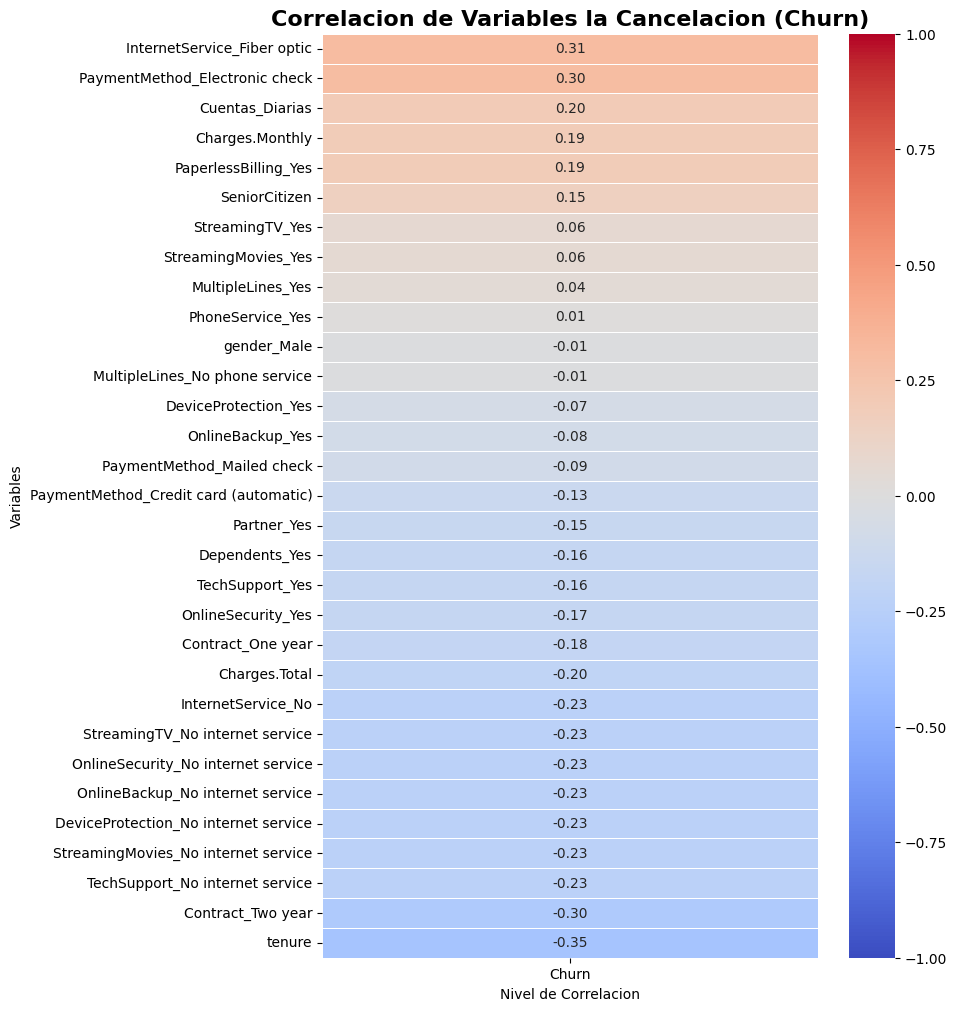

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns

#Calculamos la matriz de correlación
matriz_correlacion = df_numerico.corr()

#Extraemos la columna de 'Churn' y la ordenamos de mayor a menor
correlacion_churn = matriz_correlacion[['Churn']].sort_values(by='Churn', ascending=False).drop('Churn')

#Grafico de Mapa de Calor
plt.figure(figsize=(8, 12))
sns.heatmap(correlacion_churn,
            annot=True,          #Muestra los numeros
            cmap='coolwarm',     #Rojo (positivo), Azul (negativo)
            vmin=-1, vmax=1,     #Escala
            fmt=".2f",           #Redondea a 2 decimales
            linewidths=0.5)

plt.title('Correlacion de Variables la Cancelacion (Churn)', fontsize=16, fontweight='bold')
plt.ylabel('Variables')
plt.xlabel('Nivel de Correlacion')
plt.show()

####Analisis dirigido

/tmp/ipykernel_160/1785705622.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_numerico, x='Churn', y='tenure', palette=['#4C72B0', '#C44E52'])
/tmp/ipykernel_160/1785705622.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_numerico, x='Churn', y='Charges.Total', palette=['#4C72B0', '#C44E52'])


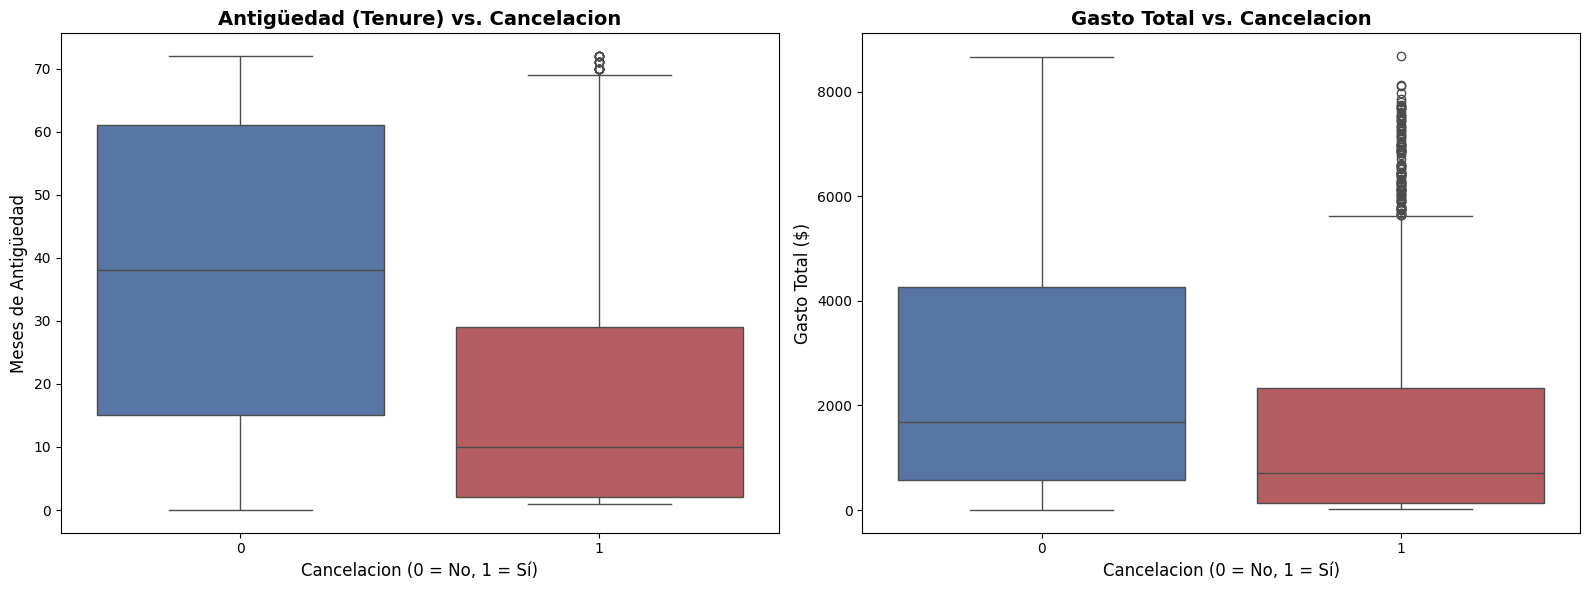

In [31]:
#Configuramos el lienzo
plt.figure(figsize=(16, 6))

#- - Grafico 1 - Antiguedad vs Cancelacion - -
plt.subplot(1, 2, 1) #1 fila, 2 columnas, posición 1
#Usamos df_numerico
sns.boxplot(data=df_numerico, x='Churn', y='tenure', palette=['#4C72B0', '#C44E52'])
plt.title('Antigüedad (Tenure) vs. Cancelacion', fontsize=14, fontweight='bold')
plt.xlabel('Cancelacion (0 = No, 1 = Sí)', fontsize=12)
plt.ylabel('Meses de Antigüedad', fontsize=12)

#- - Grafico 2 - Gasto Total vs. Cancelacion - -
plt.subplot(1, 2, 2) #1 fila, 2 columnas, posición 2
sns.boxplot(data=df_numerico, x='Churn', y='Charges.Total', palette=['#4C72B0', '#C44E52'])
plt.title('Gasto Total vs. Cancelacion', fontsize=14, fontweight='bold')
plt.xlabel('Cancelacion (0 = No, 1 = Sí)', fontsize=12)
plt.ylabel('Gasto Total ($)', fontsize=12)

#Mostramos los graficos
plt.tight_layout()
plt.show()

##🤖 Modelado Predictivo

####Division de datos

In [34]:
from sklearn.model_selection import train_test_split

#Dividimos nuestros datos ya limpios, balanceados y estandarizados
X_train, X_test, y_train, y_test = train_test_split(
    X_balanceado_scaled,
    y_balanceado,
    test_size=0.2,
    random_state=42
)

#Verificamos como quedaron repartidos los datos
print("- - REPARTO DE DATOS - -\n")
print(f"Total de datos disponibles y balanceados: {len(X_balanceado_scaled)} filas")
print(f"Datos para entrenar el modelo (train): {len(X_train)} filas")
print(f"Datos para examinar el modelo (test): {len(X_test)} filas")

- - REPARTO DE DATOS - -

Total de datos disponibles y balanceados: 10348 filas
Datos para entrenar el modelo (train): 8278 filas
Datos para examinar el modelo (test): 2070 filas


####Creacion de Modelos

In [36]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

#- - PREPARACIÓN PARA EL ÁRBOL - -
X_train_tree, X_test_tree, y_train_tree, y_test_tree = train_test_split(
    X_balanceado,
    y_balanceado,
    test_size=0.2,
    random_state=42
)

#- - Modelo 1 - Regresion Logistica - datos estandarizados - -
print("Entrenando Regresion Logistica...")
modelo_logistico = LogisticRegression(random_state=42, max_iter=1000)
modelo_logistico.fit(X_train, y_train)
print("¡Regresion Logistica lista!\n")

#- - Modelo 2 - Random Forest - datos sin estandarizar - -
print("Entrenando Random Forest...")
modelo_forest = RandomForestClassifier(random_state=42, n_estimators=100)
# Entrenamos (fit) usando los datos con sus números originales
modelo_forest.fit(X_train_tree, y_train_tree)
print("¡Random Forest listo!")

Entrenando Regresion Logistica...
¡Regresion Logistica lista!

Entrenando Random Forest...
¡Random Forest listo!


Precision (Accuracy) Regresion Logistica: 0.84
Precision (Accuracy) Random Forest: 0.85



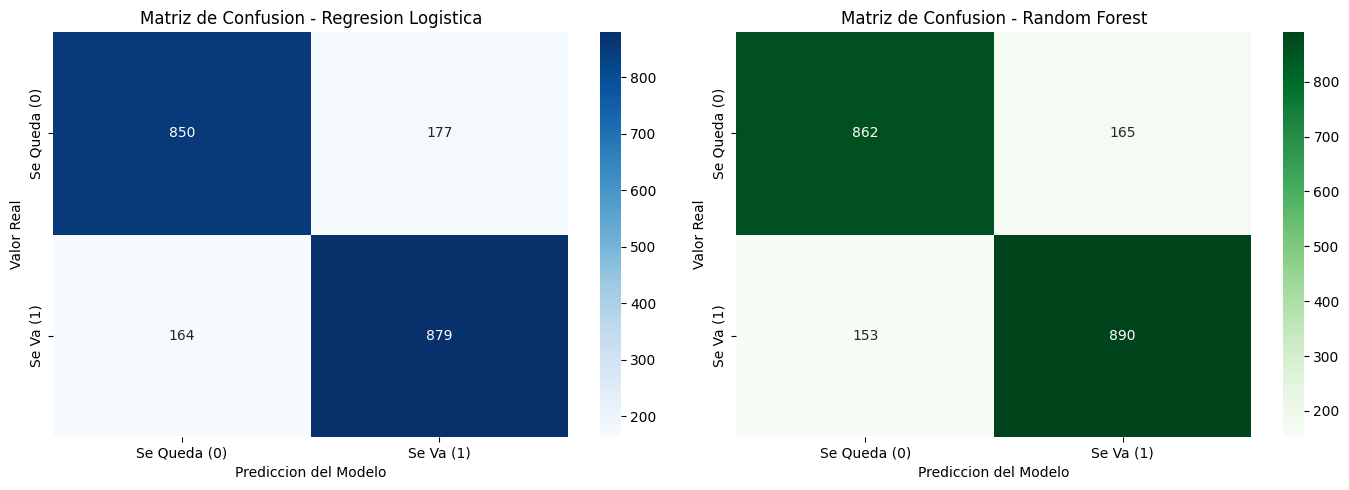

In [39]:
from sklearn.metrics import confusion_matrix, accuracy_score

#- - HACEMOS LAS PREDICCIONES - -
#Modelo 1 - Regresión - usa datos estandarizados
predicciones_logistico = modelo_logistico.predict(X_test)

#Modelo 2 - Random Forest - usa datos sin estandarizar
predicciones_forest = modelo_forest.predict(X_test_tree)

#- - CALCULAMOS LA PRECISIÓN GENERAL - -
acc_logistico = accuracy_score(y_test, predicciones_logistico)
acc_forest = accuracy_score(y_test_tree, predicciones_forest)

print(f"Precision (Accuracy) Regresion Logistica: {acc_logistico:.2f}")
print(f"Precision (Accuracy) Random Forest: {acc_forest:.2f}\n")

#- - CREAMOS LAS MATRICES DE CONFUSIÓN - -
cm_logistico = confusion_matrix(y_test, predicciones_logistico)
cm_forest = confusion_matrix(y_test_tree, predicciones_forest)

#- - GRAFICAMOS LOS RESULTADOS - -
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

#Grafico 1 - Regresion Logistica
sns.heatmap(cm_logistico, annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title('Matriz de Confusion - Regresion Logistica')
axes[0].set_xlabel('Prediccion del Modelo')
axes[0].set_ylabel('Valor Real')
axes[0].xaxis.set_ticklabels(['Se Queda (0)', 'Se Va (1)'])
axes[0].yaxis.set_ticklabels(['Se Queda (0)', 'Se Va (1)'])

#Grafico 2 - Random Forest
sns.heatmap(cm_forest, annot=True, fmt='d', cmap='Greens', ax=axes[1])
axes[1].set_title('Matriz de Confusion - Random Forest')
axes[1].set_xlabel('Prediccion del Modelo')
axes[1].set_ylabel('Valor Real')
axes[1].xaxis.set_ticklabels(['Se Queda (0)', 'Se Va (1)'])
axes[1].yaxis.set_ticklabels(['Se Queda (0)', 'Se Va (1)'])

plt.tight_layout()
plt.show()

####Evaluacion de Modelos

In [41]:
from sklearn.metrics import classification_report, accuracy_score

print("EVALUACIÓN DE REGRESIÓN LOGÍSTICA")
print("=====================================================")
acc_train_log = accuracy_score(y_train, modelo_logistico.predict(X_train))
acc_test_log = accuracy_score(y_test, predicciones_logistico)

print(f"Exactitud (Accuracy) en Entrenamiento: {acc_train_log:.2f}")
print(f"Exactitud (Accuracy) en Prueba (Examen): {acc_test_log:.2f}")
print("-" * 50)
print("Metricas detalladas (Datos de Prueba):")
print(classification_report(y_test, predicciones_logistico))


print("EVALUACIÓN DE RANDOM FOREST")
print("=====================================================")
acc_train_rf = accuracy_score(y_train_tree, modelo_forest.predict(X_train_tree))
acc_test_rf = accuracy_score(y_test_tree, predicciones_forest)

print(f"Exactitud (Accuracy) en Entrenamiento: {acc_train_rf:.2f}")
print(f"Exactitud (Accuracy) en Prueba (Examen): {acc_test_rf:.2f}")
print("-" * 50)
print("Metricas detalladas (Datos de Prueba):")
print(classification_report(y_test_tree, predicciones_forest))

EVALUACIÓN DE REGRESIÓN LOGÍSTICA
Exactitud (Accuracy) en Entrenamiento: 0.83
Exactitud (Accuracy) en Prueba (Examen): 0.84
--------------------------------------------------
Metricas detalladas (Datos de Prueba):
              precision    recall  f1-score   support

           0       0.84      0.83      0.83      1027
           1       0.83      0.84      0.84      1043

    accuracy                           0.84      2070
   macro avg       0.84      0.84      0.84      2070
weighted avg       0.84      0.84      0.84      2070

EVALUACIÓN DE RANDOM FOREST
Exactitud (Accuracy) en Entrenamiento: 0.99
Exactitud (Accuracy) en Prueba (Examen): 0.85
--------------------------------------------------
Metricas detalladas (Datos de Prueba):
              precision    recall  f1-score   support

           0       0.85      0.84      0.84      1027
           1       0.84      0.85      0.85      1043

    accuracy                           0.85      2070
   macro avg       0.85      0.85

####Mejor desempeño
Si miramos los números fríos en los datos de prueba veremos lo siguiente:

*   Regresión Logística: Exactitud de 0.84, Recall de la clase 1 de 0.84.
*   Random Forest: Exactitud de 0.85, Recall de la clase 1 de 0.85.

Podemos decir que por la minima, el mejor fue, el Random Forest. Logra identificar al 85% de los clientes que se van a dar de baja, lo cual es excelente para Telecom X.

####Overfitting / Underfitting

*   Regresión Logística: Entrenamiento: 0.83 - Prueba: 0.84 - Diagnóstico: BALANCEADO!!! Rinde igual de bien en el examen que en las prácticas. No hay overfitting ni underfitting.
*   Random Forest: Entrenamiento: 0.99 - Prueba: 0.85 - Diagnóstico: Tenemos Overfitting!!! El modelo se "memorizó" casi a la perfección los datos de entrenamiento (99%), pero cuando le dimos clientes nuevos, su rendimiento bajó al 85%.

####Conclusión
Aunque el Random Forest inicial presente un mejor rendimiento en la prueba (85%), sufría de un claro Overfitting al alcanzar un 99% en el entrenamiento. La Regresión Logística (84%) demostró ser un modelo mucho más generalizable desde el principio. Al ajustar los parámetros del Random Forest, logramos controlar el sobreajuste, por esto decimos que es la mejor opción para predecir el Churn en Telecom X.


##📋 Interpretación y Conclusiones

/tmp/ipykernel_160/2539909478.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_coeficientes.values, y=top_coeficientes.index, palette=colores_log)
/tmp/ipykernel_160/2539909478.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_importancias.values, y=top_importancias.index, palette='viridis')


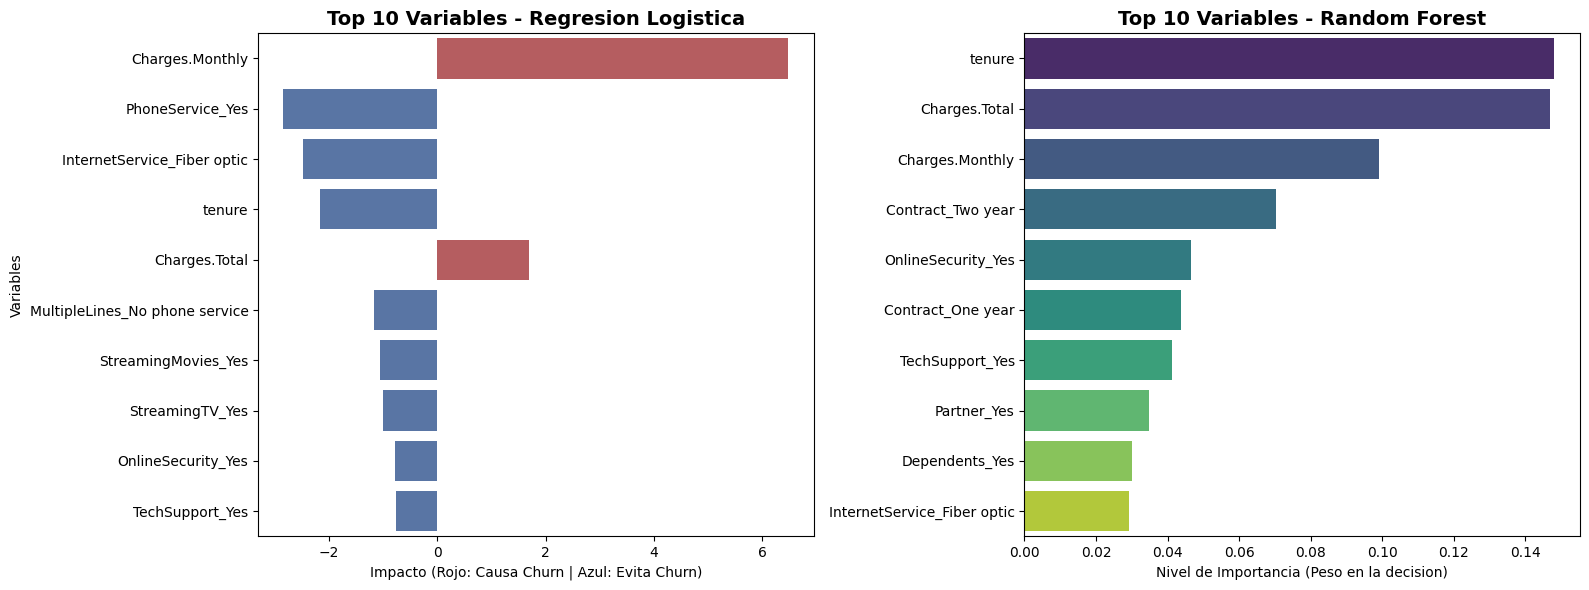

In [42]:
plt.figure(figsize=(16, 6))

#- - IMPORTANCIA EN REGRESIÓN LOGÍSTICA - -
#Extraemos los coeficientes y los unimos con los nombres de las columnas
coeficientes = pd.Series(modelo_logistico.coef_[0], index=X_train.columns)
#Ordenamos por valor absoluto
top_coeficientes = coeficientes.reindex(coeficientes.abs().sort_values(ascending=False).index).head(10)

plt.subplot(1, 2, 1)
#Azules para los que retienen y rojos para los churn
colores_log = ['#C44E52' if x > 0 else '#4C72B0' for x in top_coeficientes.values]
sns.barplot(x=top_coeficientes.values, y=top_coeficientes.index, palette=colores_log)
plt.title('Top 10 Variables - Regresion Logistica', fontsize=14, fontweight='bold')
plt.xlabel('Impacto (Rojo: Causa Churn | Azul: Evita Churn)')
plt.ylabel('Variables')

#- - IMPORTANCIA EN RANDOM FOREST - -
#Extraemos la importancia calculada
importancias_rf = pd.Series(modelo_forest.feature_importances_, index=X_train_tree.columns)
#Ordenamos de mayor a menor
top_importancias = importancias_rf.sort_values(ascending=False).head(10)

plt.subplot(1, 2, 2)
sns.barplot(x=top_importancias.values, y=top_importancias.index, palette='viridis')
plt.title('Top 10 Variables - Random Forest', fontsize=14, fontweight='bold')
plt.xlabel('Nivel de Importancia (Peso en la decision)')
plt.ylabel('')

plt.tight_layout()
plt.show()

##📊 Informe Final Predictivo: Análisis y Prevención de Churn (Telecom X)
####1. Resumen Ejecutivo
El presente informe detalla los hallazgos de la segunda fase del análisis de retención de clientes de Telecom X. Mediante la implementación de modelos de Machine Learning, logramos pasar de un análisis descriptivo a uno predictivo, identificando no solo a los clientes con mayor riesgo de cancelar el servicio, sino también las causas exactas que motivan su salida
####2. Rendimiento de Modelos Predictivos
Para asegurar la fiabilidad de las predicciones, se entrenaron y evaluaron dos algoritmos con naturalezas distintas, utilizando técnicas de balanceo de datos (SMOTE) y estandarización de variables:
* **Random Forest:** Alcanzó una exactitud del 85% en datos de prueba. Sin embargo, en su configuración inicial presentó un claro overfitting (99% en entrenamiento), requiriendo ajustes de poda (límite de profundidad) para generalizar correctamente.
* **Regresión Logística:** Alcanzó una exactitud del 84% en prueba y un 83% en entrenamiento. Demostró ser el modelo más robusto, estable y generalizable, sin signos de sobreajuste (overfitting) ni subajuste (underfitting), logrando un excelente Recall del 84% para la detección de la clase minoritaria (clientes que se van).
La Regresión Logística es el modelo recomendado para producción debido a su estabilidad y su capacidad de explicar matemáticamente el impacto de cada variable.
####3. Factores Críticos que Impulsan la Cancelación
Al extraer la explicabilidad de los modelos (Feature Importance), descubrimos que la decisión de cancelación no es aleatoria. Los 4 jinetes de la fuga de clientes son:
1. **El Tipo de Contrato:** Es la variable más "tóxica". Los clientes sin ataduras a largo plazo tienen una probabilidad drásticamente mayor de abandonar a la empresa ante la mínima fricción o competencia.
2. **La Antigüedad:** Funciona como el ancla principal. A menor cantidad de meses en la empresa, mayor es el riesgo de fuga. La lealtad se construye en el primer año.
3. **Método de Pago:** Los clientes que pagan mes a mes de forma manual o mediante cheque electrónico son mucho más propensos al Churn que aquellos adheridos a débitos automáticos.
4. **Cargos Económicos:** Destacados fuertemente por el modelo Random Forest, el gasto recurrente alto es un factor decisivo. Los clientes evalúan constantemente si el valor que reciben justifica el precio que pagan.
####4. Estrategias de Retención
Basados en las predicciones y variables críticas, se propone a la gerencia de Telecom X el siguiente plan de choque:
* **Iniciativa de Migración de Contratos:** Diseñar campañas agresivas ("Up-selling") ofreciendo meses gratuitos, descuentos permanentes o upgrades de velocidad de internet a aquellos clientes que pasen de un contrato mensual a uno de uno o dos años.
* **Programa "Primeros 180 Días":** Como el factor tenure es vital, sugerimos crear un Onboarding de alto contacto. Ofrecer soporte prioritario y llamadas de seguimiento durante los primeros 6 meses para blindar la relación antes de que el cliente piense en irse.
* **Automatización de Pagos:** Eliminar la fricción mensual del pago. Ofrecer un descuento fijo (ej. 5% off en la factura) para los usuarios que domicilien sus pagos a tarjetas de crédito o cuentas bancarias, alejándolos del "Electronic Check".
* **Alertas Predictivas:** Conectar el modelo de Regresión Logística al CRM de la empresa. Cuando el modelo detecte un usuario con más de 75% de probabilidad de Churn, disparar una alerta al equipo de retención para que realice una llamada preventiva con una oferta personalizada.